In [1]:
from platform import python_version
print(python_version())

3.11.14


In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as npmtd
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

sys.path.insert(1, '../src/')

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import *
from libs.MTD_lib import MTD
from libs.GDC_lib import GDC
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'TCGA-BRCA'
PSI_ID = 'TCGA-ACC'
PSI_ID = 'TCGA-CESC'
PSI_ID = 'TCGA-PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD/config/all_lfc_cutoffs_TCGA-PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=False, verbose=False)
# print("\nEcho Parameters:")
# print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD
>>> Tumor


### Get all programs

In [5]:
gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

#--------- chose a disease --------------------
DISEASE_ID = 'ACC'
DISEASE_ID = 'PAAD'

In [6]:
verbose=False
force=False

method='deseq2'
imax_tumor=250
imax_normal=50

gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

exclude_prog_list=['CCLE']

dfn_tumor, dfn_normal, dic = gdc.get_all_data_from_disease(disease_id=DISEASE_ID, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list)
print("\n")
print(">> dfn_tumor", dfn_tumor.shape)
print(">> dfn_normal", dfn_normal.shape)
dfn_tumor.head(3)

2) prog_id CPTAC, psi_id PAAD, primary_site Pancreas, disease_id PAAD df_tumor (60616, 216)
3) prog_id CPTAC, psi_id PAAD_GDC, primary_site Pancreas, disease_id PAAD df_tumor (60616, 216)
4) prog_id TCGA, psi_id TCGA-PAAD, primary_site Pancreas, disease_id PAAD df_tumor (60616, 34)
There are 457 tumor samples and 101 control samples merging studies
Normal: Removing 1 columns with values > 198.5165501925616 -> [101]
Table saved ((60616, 460)) at '/home/flavio/uv/perturb_agent/data/multi_progs/lfc/expression_tumor_counts_all_samples.tsv'
Table saved ((60616, 103)) at '/home/flavio/uv/perturb_agent/data/multi_progs/lfc/expression_normal_counts_all_samples.tsv'


>> dfn_tumor (60616, 460)
>> dfn_normal (60616, 103)


,geneid,symbol,biotype,1,2,3,4,5,6,7,...,448,449,450,451,452,453,454,455,456,457
0,ENSG00000000003,TSPAN6,protein_coding,18,0,6,2,7,0,4,...,1060,1221,210,18,155,36,84,182,323,192
1,ENSG00000000005,TNMD,protein_coding,39,23,3,15,13,13,10,...,0,1,87,4,2,0,1,8,1,0
2,ENSG00000000419,DPM1,protein_coding,48,11,13,5,27,5,5,...,1056,843,474,711,493,744,528,457,447,524


In [7]:
dfn_normal.head(3)

,geneid,symbol,biotype,1,2,3,4,5,6,7,...,91,92,93,94,95,96,97,98,99,100
0,ENSG00000000003,TSPAN6,protein_coding,1,1,0,1,0,2,1,...,0,0,1,1,1,1,0,2,0,0
1,ENSG00000000005,TNMD,protein_coding,7,10,14,3,7,14,5,...,11,13,3,9,16,12,17,9,7,9
2,ENSG00000000419,DPM1,protein_coding,6,3,2,2,0,6,8,...,11,4,6,9,7,5,15,5,1,9


In [8]:
for i, dic2 in dic.items():
    print(f"{i}: {dic2['prog_id']} {dic2['psi_id']} {dic2['primary_site']}")

    df_tumor = dic2['df_tumor']
    df_normal = dic2['df_tumor']

    print("df_tumor", df_tumor.shape)
    print("df_normal", df_normal.shape)
    print("\n")

1: ['CPTAC'] ['PAAD'] ['Pancreas']
df_tumor (60616, 216)
df_normal (60616, 216)


2: ['CPTAC'] ['PAAD_GDC'] ['Pancreas']
df_tumor (60616, 216)
df_normal (60616, 216)


3: ['TCGA'] ['TCGA-PAAD'] ['Pancreas']
df_tumor (60616, 34)
df_normal (60616, 34)




### Clusterization

In [ ]:
dfn = dfn_normal
msg_cluster = 'Normal'


dfn = dfn_tumor
 = 'Tumor'

In [11]:
perc_min_samples = 0.25 
top_n: int = 10_000

df_sel, df_cpm,  dfg_filt, df_scaled = gdc.cluster_data(dfn.drop(columns='biotype'), perc_min_samples, top_n)
df_cpm.shape, df_sel.shape

sample_cols 457 and min_samples


((20024, 457), (457, 10000))

In [ ]:
fname = f"{msg_cluster}_expression_log_CPM_top_{top_n}_genes_all_samples_transposed.tsv"
pdwritecsv(df_sel, fname, gdc.root_mprog_lfc, verbose=True)

print(df_sel.shape)
df_sel.head(6)


Table saved ((457, 10000)) at '/home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD/lfc/Tumor_expression_log_CPM_top_10000_genes_all_samples_transposed.tsv'
(457, 10000)


geneid,ENSG00000270641,ENSG00000262619,ENSG00000281383,ENSG00000189223,ENSG00000256462,ENSG00000230535,ENSG00000229732,ENSG00000249119,ENSG00000286471,ENSG00000206072,...,ENSG00000267871,ENSG00000119280,ENSG00000286599,ENSG00000185532,ENSG00000249435,ENSG00000153132,ENSG00000246203,ENSG00000271964,ENSG00000047410,ENSG00000145246
1,14.479,10.816,3.418,13.593,0.000,7.171,0.000,9.160,7.828,1.145,...,2.975,3.012,7.552,2.081,1.387,3.445,4.117,4.291,4.150,1.687
2,13.720,10.877,0.000,13.295,0.496,8.709,5.514,0.496,8.294,3.265,...,4.087,3.202,8.000,0.000,3.202,2.350,5.956,1.952,2.838,0.000
3,14.420,12.968,10.809,13.560,1.684,9.790,0.000,8.637,9.940,1.684,...,2.440,3.300,7.099,2.440,2.111,2.708,4.387,3.128,4.896,3.719
4,13.992,12.899,0.000,13.066,2.920,10.898,2.023,0.000,8.440,2.427,...,4.944,3.078,8.258,0.907,3.908,1.460,5.499,2.305,3.630,2.171
5,14.229,14.828,11.366,13.013,0.550,11.073,0.000,9.503,10.829,0.947,...,2.814,4.482,7.463,2.236,1.731,2.372,4.220,3.807,6.694,1.258
6,12.156,9.721,5.782,13.938,0.000,8.017,2.619,0.000,2.858,0.000,...,4.760,2.334,7.772,2.703,3.793,1.680,5.280,2.929,2.334,0.452


In [13]:
df_pca = gdc.calc_PCA(df_scaled, n_components=10, verbose=False)
df_pca.shape

(457, 3)

In [14]:
df_eval, df_samp_clusters = gdc.calc_best_cluster(df_pca=df_pca, min_clusters = 6, max_clusters = 12)
df_eval

,k,silhouette
0,6,0.584
1,7,0.492
2,8,0.443
3,9,0.390
4,10,0.391
5,11,0.372
6,12,0.383


In [15]:
df_samp_clusters

,sample,cluster
0,1,3
1,2,4
2,3,3
3,4,4
4,5,3
...,...,...
452,453,2
453,454,2
454,455,2
455,456,2


In [16]:
df_samp_clusters.groupby('cluster').size()

cluster
1    202
2     33
3     78
4    102
5     24
6     18
dtype: int64

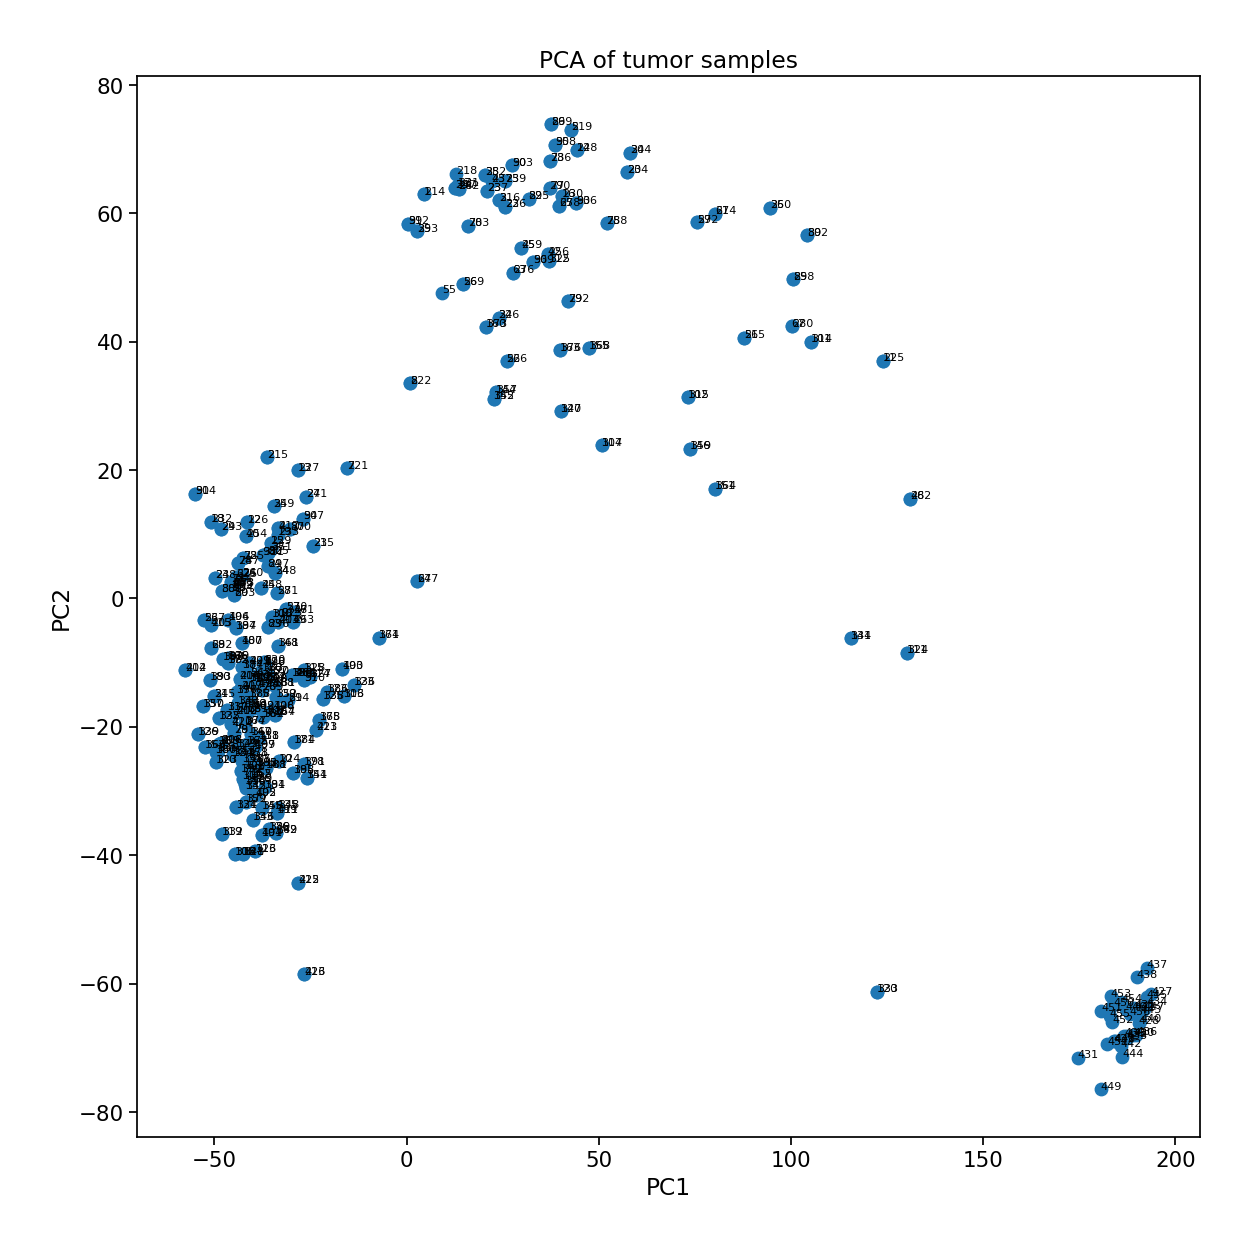

In [17]:
gdc.plot_PCA(df_pca, figsize=(12, 12))

### UMAP

In [18]:
n_neighbors=5
min_dist=0.2
metric="euclidean"

df_umap = gdc.calc_PCA_UMAP(df_pca=df_pca, df_samp_clusters=df_samp_clusters, n_neighbors=n_neighbors, min_dist=min_dist, metric=metric)

df_umap

/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


,UMAP1,UMAP2,sample,cluster
0,13.316,2.840,1,3
1,-1.155,8.181,2,4
2,17.151,1.864,3,3
3,13.226,6.906,4,4
4,-8.075,11.638,5,3
...,...,...,...,...
452,1.175,-1.345,453,2
453,1.181,-1.334,454,2
454,1.264,-1.478,455,2
455,1.174,1.401,456,2


In [20]:
df_umap.groupby('cluster').size()

cluster
1    202
2     33
3     78
4    102
5     24
6     18
dtype: int64

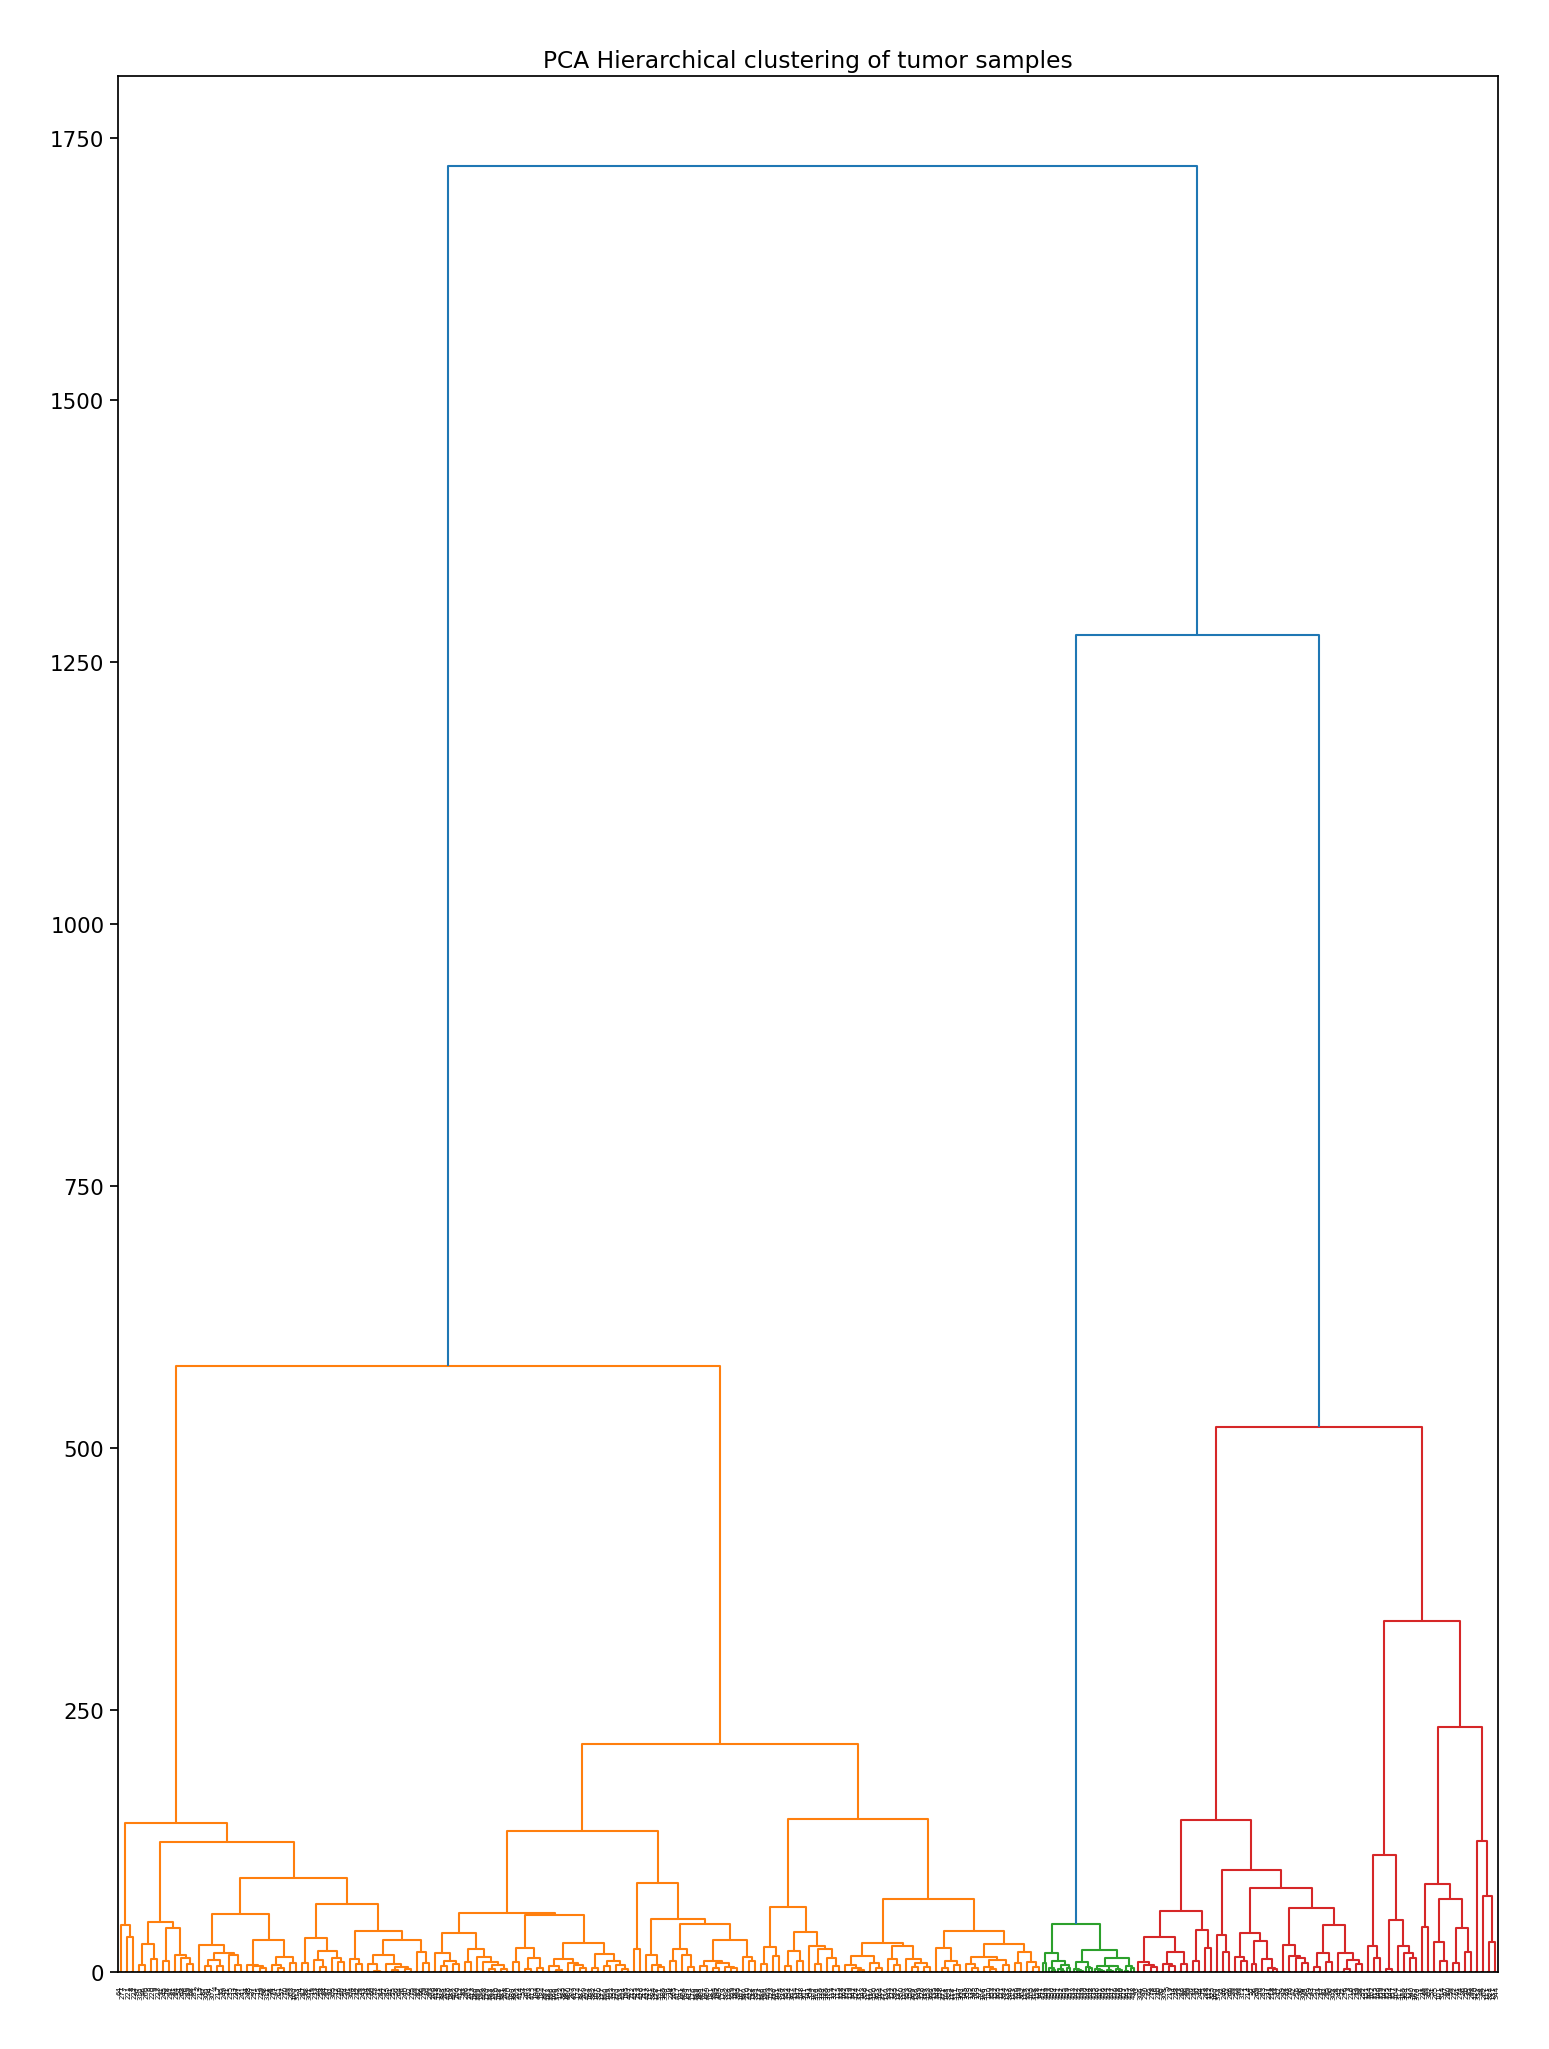

In [22]:
gdc.plot_HCA_PCA(df_pca, figsize=(15,20))

### Cut tree into k clusters:

In [ ]:
method_hca = "ward"
criterion="maxclust"
verbose = False

n_clusters=10


df_hca = gdc.cut_HCA_PCA(df_pca=df_pca, method=method_hca, n_clusters=n_clusters, criterion=criterion, verbose=verbose)

fname = f"clusters_{n_clusters}_x_tumor_samples.tsv"
pdwritecsv(df_hca, fname, gdc.root_mprog_lfc, verbose=True)

df_hca

Table saved ((457, 2)) at '/home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD/lfc/clusters_10_x_tumor_samples.tsv'


,sample,cluster
0,1,7
1,2,1
2,3,7
3,4,1
4,5,6
...,...,...
452,453,5
453,454,5
454,455,5
455,456,5


In [ ]:
pdwritecsv(df_hca, fname, gdc.root_mprog_lfc, verbose=True)


In [24]:
df_hca.groupby('cluster').size()

cluster
1     104
2     108
3      28
4      66
5      31
6      26
7      50
8      18
9      18
10      8
dtype: int64

In [27]:
dfclu_samp = df_hca.groupby('cluster').size().reset_index(name='samples')
dfclu_samp

,cluster,samples
0,1,104
1,2,108
2,3,28
3,4,66
4,5,31
5,6,26
6,7,50
7,8,18
8,9,18
9,10,8


In [ ]:
dfc_log = np.log2(df_cpm + 1)

gene_annot = (
    dfg_filt[["geneid", "symbol"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

dfall, dfsig = gdc.find_cluster_signature_genes(df_logcpm=dfc_log, df_samp_clusters=df_hca, gene_annot=gene_annot)

In [ ]:
print(len(dfall))
dfall.head(3)

In [ ]:
fname = f"{msg_cluster}_clusters_{n_clusters}_signatures_up_down_DEGs.tsv"
pdwritecsv(dfall, fname, gdc.root_mprog_lfc)

In [ ]:
import matplotlib.pyplot as plt

lfc = pd.to_numeric(dfall["lfc"], errors="coerce").dropna()

plt.figure(figsize=(9, 5))
plt.hist(lfc, bins=60, edgecolor="black", alpha=0.8)
plt.axvline(0, linestyle="--", linewidth=1)
plt.axvline(-1, linestyle=":", linewidth=1)
plt.axvline(1, linestyle=":", linewidth=1)

plt.xlabel("log2 Fold Change")
plt.ylabel("Number of genes")
plt.title("Distribution of DEG log2 Fold Changes")
plt.tight_layout()
plt.show()

In [ ]:
print(len(dfsig))
dfsig.head(3)

In [ ]:

lfc = pd.to_numeric(dfsig["lfc"], errors="coerce").dropna()

plt.figure(figsize=(9, 5))
plt.hist(lfc, bins=60, edgecolor="black", alpha=0.8)
plt.axvline(0, linestyle="--", linewidth=1)
plt.axvline(-1, linestyle=":", linewidth=1)
plt.axvline(1, linestyle=":", linewidth=1)

plt.xlabel("log2 Fold Change")
plt.ylabel("Number of genes")
plt.title("Distribution of DEG log2 Fold Changes")
plt.tight_layout()
plt.show()

In [ ]:
cluster_list = np.unique(dfall.cluster)
cluster_list

In [ ]:
LFC_cutoff=2
FDR_cutoff=1e-3

ncluster = 1

df2 = dfsig[dfsig.cluster == ncluster]
df2 = df2[ (df2['lfc'].abs() >= LFC_cutoff) & (df2['fdr'] < FDR_cutoff) ]
print(len(df2))
df2.head(3)

In [ ]:
dic = {}

for ncluster in cluster_list:
    df2 = dfsig[dfsig.cluster == ncluster]
    df2 = df2[ (df2['lfc'].abs() > LFC_cutoff) & (df2['fdr'] < FDR_cutoff) ]

    symbols = np.unique(df2.symbol)

    dic[ncluster] = set(symbols)

    print(f"Cluster {ncluster}: {len(symbols)} signature genes")

    fname = f"cluster_{ncluster}-{n_clusters}_signature_genes.txt"
    filename = gdc.root_mprog_lfc / fname

    write_txt('\n'.join(symbols), filename)


In [ ]:
df_cluster = gdc.write_clusters(dfall, dfsig, LFC_cutoff=LFC_cutoff, FDR_cutoff=FDR_cutoff, verbose=False)

df_cluster

In [ ]:
dic2 = {}

df_cluster['n_unique_genes']  = 0
df_cluster['unique_genes'] = None


for nclu in df_cluster['ncluster']:
    set0 = dic[nclu]

    for key, setx in dic.items():
        if key != nclu:
            set0 = set0 - dic[key]

    uniq_list = list(set0)
    s_lista = "; ".join(uniq_list)

    df_cluster.loc[df_cluster['ncluster'] == nclu, 'n_unique_genes'] = len(uniq_list)
    df_cluster.loc[df_cluster['ncluster'] == nclu, 'unique_genes'] = s_lista



df_cluster

In [ ]:
fname = f"clusters_{n_clusters}.tsv"
pdwritecsv(df_cluster, fname, gdc.root_mprog_lfc)



In [ ]:
gdc.root_mprog_lfc

### UMAP

In [ ]:
gdc.plot_PCA_UMAP(df_umap=df_umap, n_neighbors=n_neighbors, min_dist=min_dist, figsize=(12, 12))

In [ ]:
gdc.plot_HCA_PCA_UMAP(df_umap, figsize=(12, 8))

In [ ]:
find_cluster_signature_genes

### Loop over clusters

In [ ]:
verbose=False
force=False

method='deseq2'
imax_tumor=250
imax_normal=50

gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

case = case_list[0]
print(f"case = {case}")

df_psi = gdc.open_primary_sites_cbio(verbose=False)


df_psi = df_psi[ (df_psi.disease_id == DISEASE_ID) & (~pd.isnull(df_psi.primary_site)) & (~pd.isnull(df_psi.cbioportal_study_id)) ].copy()
dfa = df_psi.groupby(['prog_id', 'psi_id', 'disease_id', 'primary_site', 'cbioportal_study_id']).size().reset_index()

dic = {}

for ipsi, row in dfa.iterrows():
    prog_id = row.prog_id

    if prog_id == 'CCLE':
        continue

    psi_id = row.psi_id
    disease_id = row.disease_id
    primary_site = row.primary_site

    print(f"{int(ipsi)+1}) prog_id {prog_id}, psi_id {psi_id}, primary_site {primary_site}, disease_id {disease_id}", end=" ")

    _ = gdc.get_primary_sites(prog_id=prog_id, verbose=verbose)

    ret = gdc.set_primary_site(psi_id = psi_id)

    if not ret:
        print(f"Error: failed to set primary site for {prog_id} {psi_id}")
        continue

    df_lfc = pd.DataFrame()

    # print(gdc.root_project, gdc.root_disease, '\n')

    df_tumor, df_normal, df_gtex_ctrl = gdc.calc_file_expression_tumor_normal_gtex(imax_tumor=imax_tumor, imax_normal=imax_normal, force=force, verbose=verbose)
    print(f"df_tumor {df_tumor.shape}")

    df_degs, df_lfc, degs_txt, msg = gdc.calc_degs(
        prog_id = prog_id,
        psi_id = psi_id,
        root_src = gdc.root_src,
        run_conda = True,
        lfc_cutoff = 1.0,
        fdr_cutoff = 0.05,
        method = method,
        imax_tumor = imax_tumor,
        imax_normal = imax_normal,
        force = force,
        verbose = verbose,
    )

    if not df_tumor.empty:
        dic[ipsi] ={}

        dic[ipsi]['primary_site'] = [prog_id, psi_id, disease_id, primary_site]
        dic[ipsi]['df_tumor'] = df_tumor
        dic[ipsi]['degs'] = df_degs
        dic[ipsi]['lfc'] = df_lfc

        if not df_normal.empty:
            dic[ipsi]['df_normal'] = df_normal

        if not df_gtex_ctrl.empty:
            dic[ipsi]['df_gtex'] = df_gtex_ctrl

        print(f"Tumor samples: {df_tumor.shape[1]}, Normal samples: {df_normal.shape[1]}, GTEx controls: {df_gtex_ctrl.shape[1]}\n")

    print("")

print("\n--------------- end ---------------")

